# RuleConEx — Démonstration complète DLBAC

**RuleConEx** combine en une seule passe forward :
- **HyConEx** : importances locales + contrefactuels (`x' = x - W_c`)
- **HyperLogic** : règles IF-THEN diversifiées (Monte Carlo M1/M2)
- **Branche deep** optionnelle (TabResNet léger)

> Environnement `hyconex` + GPU. Le notebook peut être ouvert depuis `ruleconex/` ou `HyConEx_from_scratch/`.

In [7]:
import sys
from pathlib import Path

def find_hyconex_root() -> Path:
    """Trouve HyConEx_from_scratch (où vit prepare_dlbac_datasets.py)."""
    here = Path.cwd().resolve()
    for base in [here, *here.parents]:
        if (base / "prepare_dlbac_datasets.py").is_file():
            return base
        if base.name == "HyConEx_from_scratch" and (base / "ruleconex").is_dir():
            return base
    nb_dir = here / "ruleconex"
    if (here / "prepare_dlbac_datasets.py").is_file():
        return here
    if here.name == "ruleconex" and (here.parent / "prepare_dlbac_datasets.py").is_file():
        return here.parent
    raise RuntimeError(
        "Impossible de trouver HyConEx_from_scratch. "
        "Ouvrez le notebook depuis ruleconex/ ou HyConEx_from_scratch/."
    )

ROOT = find_hyconex_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import torch

if not torch.cuda.is_available():
    raise RuntimeError("CUDA requis : lancez ce notebook sur une machine avec GPU.")

import importlib
import ruleconex.utils as _rc_utils
importlib.reload(_rc_utils)

from prepare_dlbac_datasets import discover_dlbac_datasets
from ruleconex.config import RuleConExConfig
from ruleconex.evaluate import classification_metrics, evaluate_ruleconex
from ruleconex.trainer import RuleConExTrainer
from ruleconex.utils import explain_sample, extract_rules_from_pack, format_rules_text, counterfactual_report
from ruleconex.visualize import (
    plot_confusion_matrix,
    plot_counterfactual_metrics,
    plot_importance_heatmap,
    plot_metrics_table,
    plot_roc_pr_curves,
    plot_rules_bar,
    plot_threshold_sweep,
    plot_training_history,
    plot_tsne_embeddings,
    render_explanation_figure,
)
from sklearn.metrics import classification_report
from train_nouveau_module_dlbac_quantile import build_onehot_splits

plt.rcParams["figure.figsize"] = (10, 4)
SEED = 42
DEVICE = torch.device("cuda")
print("ROOT:", ROOT)
print("GPU:", torch.cuda.get_device_name(0))


ROOT: D:\ecole\master 2\recherche\INN\projet\HyConEx_from_scratch
GPU: NVIDIA GeForce 940MX


## 1. Chargement des données DLBAC (one-hot)

In [8]:
DATASET = "u4k-r4k-auth11k"  # jeux synthétiques DLBAC ; autres : u4k-r4k-auth21k, u5k-r5k-auth12k, ...

specs = {s.name: s for s in discover_dlbac_datasets()}
print("Jeux disponibles:", sorted(specs.keys())[:6], "...")

splits = build_onehot_splits(specs[DATASET], random_state=SEED)
print(f"Dataset: {splits.name}")
print(f"Train {splits.x_train.shape} | Val {splits.x_val.shape} | Test {splits.x_test.shape}")
print(f"Classes ({splits.num_classes}):", splits.class_names[:8], "...")

Jeux disponibles: ['amazon1', 'amazon2', 'amazon3', 'u4k-r4k-auth11k', 'u4k-r4k-auth21k', 'u4k-r4k-auth22k'] ...
Dataset: u4k-r4k-auth11k
Train (7017, 157) | Val (1755, 157) | Test (2192, 157)
Classes (16): ['ops_pattern_0', 'ops_pattern_1', 'ops_pattern_2', 'ops_pattern_3', 'ops_pattern_4', 'ops_pattern_5', 'ops_pattern_6', 'ops_pattern_7'] ...


## 2. Entraînement RuleConEx

  GPU=NVIDIA GeForce 940MX | batch=128 | rules=48 | MC=3
epoch   1 | loss=1.4443 train_acc=0.960 val_acc=0.927
epoch   5 | loss=0.1424 train_acc=0.992 val_acc=0.971
epoch  10 | loss=0.0950 train_acc=0.995 val_acc=0.973
epoch  15 | loss=0.0809 train_acc=0.996 val_acc=0.971
epoch  20 | loss=0.0616 train_acc=0.996 val_acc=0.974
epoch  25 | loss=0.0592 train_acc=0.995 val_acc=0.968
epoch  30 | loss=0.0562 train_acc=0.998 val_acc=0.977
Branches: (0.4285714328289032, 0.4285714328289032, 0.1428571343421936)
Règles sur entrée brute: True
Meilleure accuracy validation : 0.9840


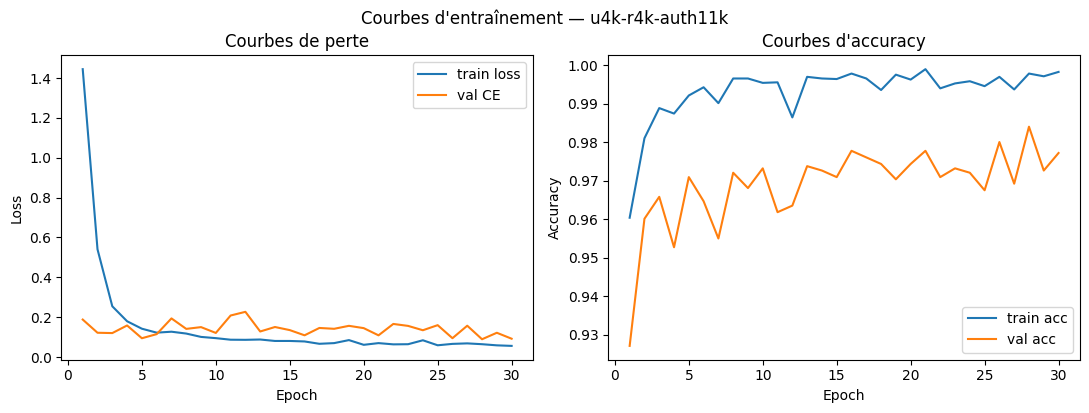

In [9]:
cfg = RuleConExConfig(
    seed=SEED,
    epochs=30 if not DATASET.startswith("amazon") else 20,
    batch_size=128,
    mc_train_samples=3,
    mc_infer_samples=5,
    num_rules=48,
)

trainer = RuleConExTrainer(cfg, device="cuda")
result = trainer.fit(
    splits.x_train,
    splits.y_train,
    splits.x_val,
    splits.y_val,
    feature_names=splits.feature_names,
    class_names=splits.class_names,
    verbose=True,
)

model = trainer.model
assert model is not None
print("Branches:", model.branch_weights())
print("Règles sur entrée brute:", model.rules_on_input)
print(f"Meilleure accuracy validation : {result.best_val_accuracy:.4f}")

fig_hist = plot_training_history(result.history)
fig_hist.suptitle(f"Courbes d'entraînement — {DATASET}", y=1.02)
plt.show()

## 3. Évaluation — métriques et courbes (train / val / test)


--- Train (7017 échantillons) ---
  accuracy          : 0.9979
  f1_macro          : 0.9974
  precision_macro   : 0.9976
  recall_macro      : 0.9974

--- Validation (1755 échantillons) ---
  accuracy          : 0.9840
  f1_macro          : 0.9837
  precision_macro   : 0.9846
  recall_macro      : 0.9835

--- Test (argmax) ---
  accuracy          : 0.9758
  f1_macro          : 0.9741
  precision_macro   : 0.9743
  recall_macro      : 0.9746

--- Métriques contrefactuelles (test) ---
  validity_cf: 0.9672
  changed_features_mean: 10.8328
  proximity_l1_mean: 42.1490
  flip_success_rate: 1.0000
  n_samples_evaluated: 128.0000
  n_counterfactuals: 1920.0000

--- Rapport de classification (test) ---
                precision    recall  f1-score   support

 ops_pattern_0       0.98      0.97      0.98       285
 ops_pattern_1       0.98      0.94      0.96       148
 ops_pattern_2       0.99      0.98      0.99       121
 ops_pattern_3       0.99      0.93      0.96       107
 ops_pattern_

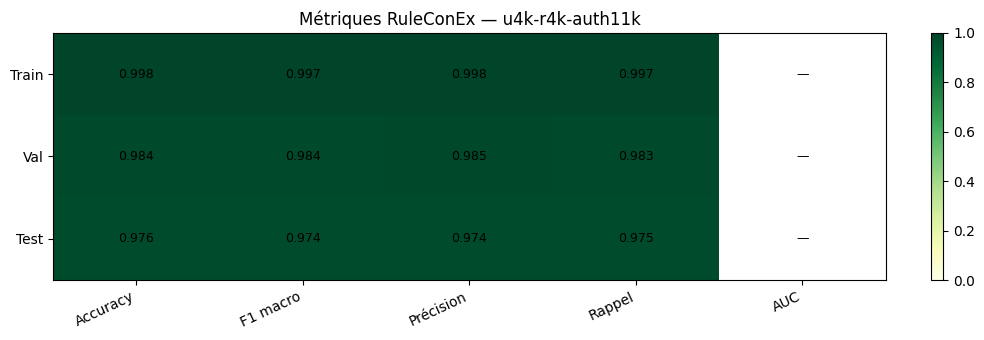

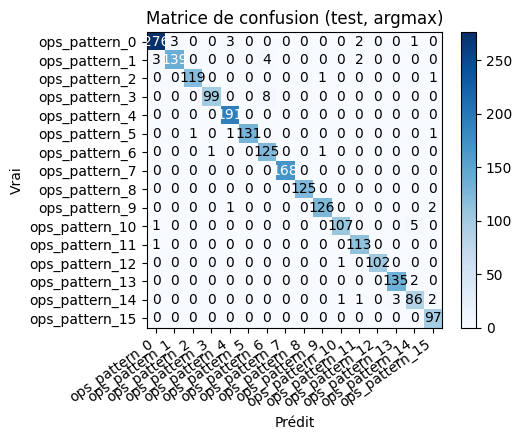

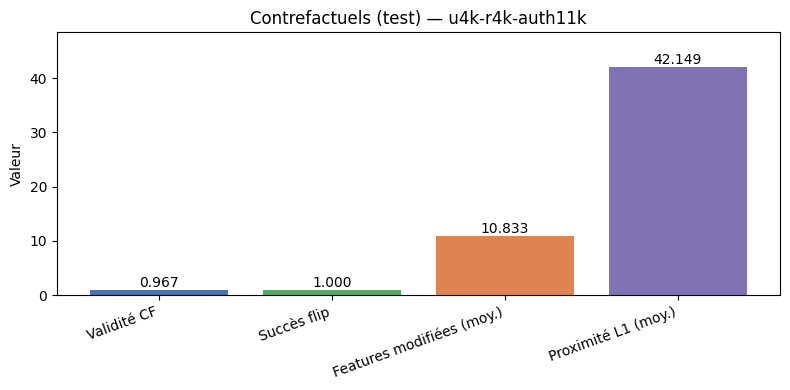

In [10]:
def _eval_split(name: str, X: np.ndarray, y: np.ndarray) -> tuple[dict[str, float], np.ndarray, np.ndarray]:
    proba = trainer.predict_proba(X)
    pred = proba.argmax(axis=1)
    metrics = classification_metrics(y, pred, proba)
    print(f"\n--- {name} ({len(y)} échantillons) ---")
    for k, v in metrics.items():
        print(f"  {k:18s}: {v:.4f}")
    return metrics, pred, proba


metrics_train, pred_train, proba_train = _eval_split("Train", splits.x_train, splits.y_train)
metrics_val, pred_val, proba_val = _eval_split("Validation", splits.x_val, splits.y_val)

eval_out = evaluate_ruleconex(trainer, splits.x_test, splits.y_test, tune_threshold=True)
metrics_test = eval_out["metrics"]
pred_test = eval_out["y_pred"]
proba_test = eval_out["y_proba"]

print("\n--- Test (argmax) ---")
for k, v in metrics_test.items():
    print(f"  {k:18s}: {v:.4f}")

if "tuned_metrics" in eval_out:
    print(f"\n--- Seuil grant optimisé (deny F1) : {eval_out['threshold']:.3f} ---")
    for k, v in eval_out["tuned_metrics"].items():
        if k != "confusion_matrix":
            print(f"  {k}: {v}")

if "counterfactuals" in eval_out:
    print("\n--- Métriques contrefactuelles (test) ---")
    for k, v in eval_out["counterfactuals"].items():
        print(f"  {k}: {v:.4f}")

print("\n--- Rapport de classification (test) ---")
print(classification_report(splits.y_test, pred_test, target_names=splits.class_names, zero_division=0))

metrics_by_split = {"Train": metrics_train, "Val": metrics_val, "Test": metrics_test}
plot_metrics_table(metrics_by_split, title=f"Métriques RuleConEx — {DATASET}")
plt.show()

plot_confusion_matrix(
    splits.y_test,
    pred_test,
    splits.class_names,
    title="Matrice de confusion (test, argmax)",
)
plt.show()

if splits.num_classes == 2:
    fig_roc = plot_roc_pr_curves(splits.y_test, proba_test, title="Courbes ROC et PR (test)")
    if fig_roc is not None:
        plt.show()

    fig_thr = plot_threshold_sweep(splits.y_test, proba_test)
    if fig_thr is not None:
        plt.show()

if "counterfactuals" in eval_out:
    plot_counterfactual_metrics(eval_out["counterfactuals"], title=f"Contrefactuels (test) — {DATASET}")
    plt.show()

## 4. Visualisations : t-SNE, heatmap d'importances, règles IF-THEN

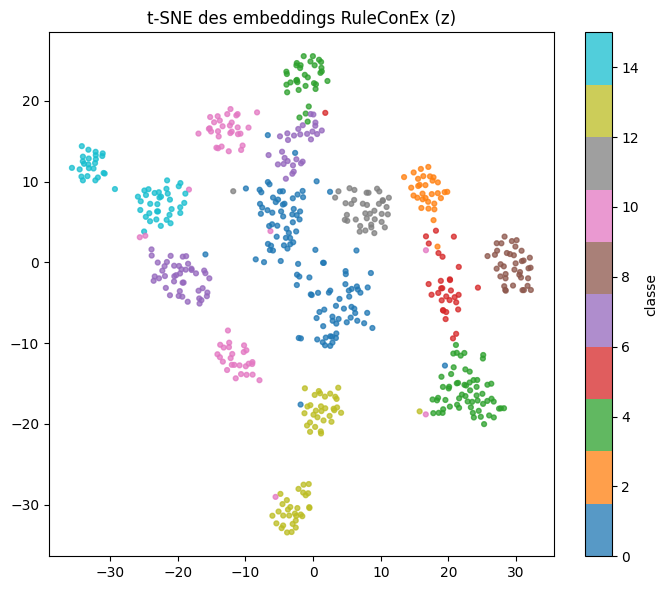

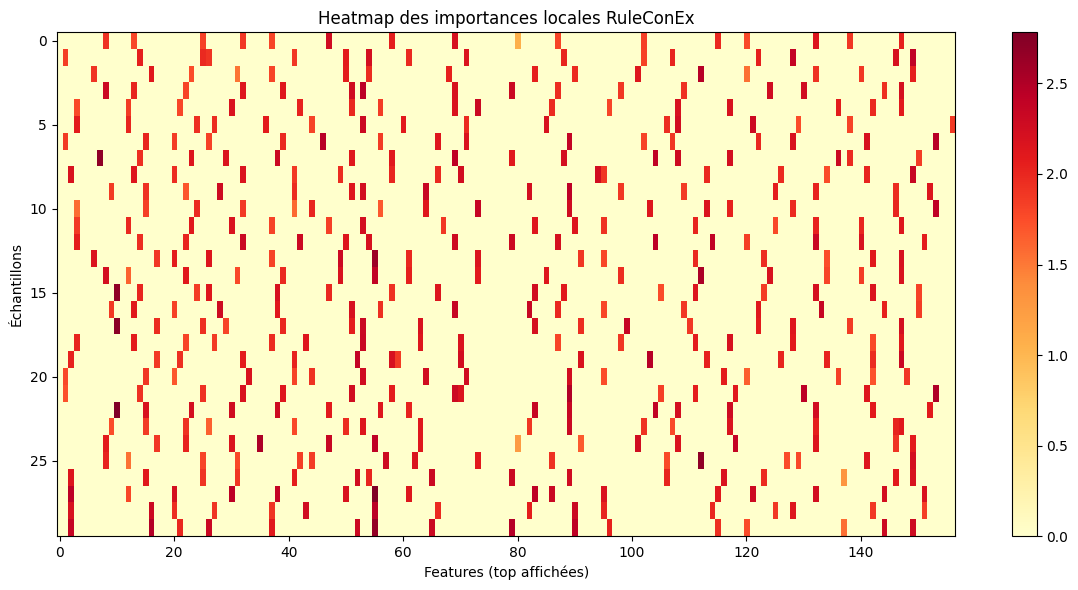

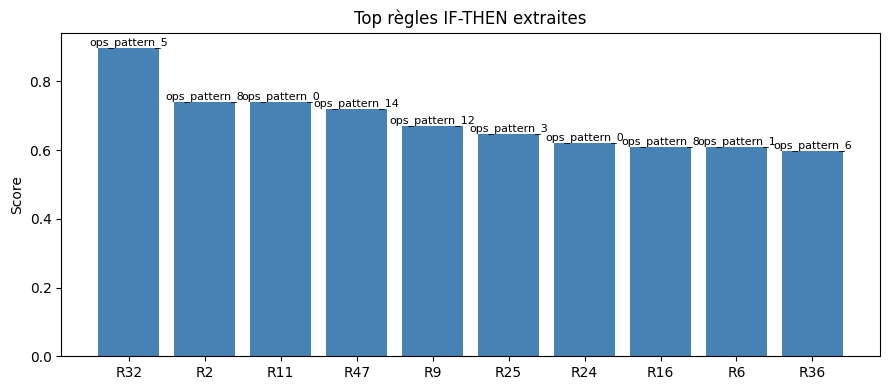

Règles IF-THEN extraites (HyperLogic)
R32 | IF oh_48=-1 AND oh_115=+1 AND oh_133=-1 AND oh_93=+1
     THEN ops_pattern_5  (confiance=0.897)

R02 | IF oh_91=+1 AND oh_129=-1 AND oh_88=-1 AND oh_137=-1
     THEN ops_pattern_8  (confiance=0.740)

R11 | IF oh_64=+1 AND oh_26=+1 AND oh_108=-1 AND oh_155=-1
     THEN ops_pattern_0  (confiance=0.739)

R47 | IF oh_41=-1 AND oh_110=+1 AND oh_52=-1 AND oh_121=-1
     THEN ops_pattern_14  (confiance=0.720)

R09 | IF oh_14=+1 AND oh_74=-1 AND oh_75=-1 AND oh_59=-1
     THEN ops_pattern_12  (confiance=0.671)

R25 | IF oh_106=-1 AND oh_141=-1 AND oh_135=-1 AND oh_119=+1
     THEN ops_pattern_3  (confiance=0.648)

R24 | IF oh_154=-1 AND oh_15=+1 AND oh_71=+1 AND oh_53=+1
     THEN ops_pattern_0  (confiance=0.620)

R16 | IF oh_34=-1 AND oh_33=-1 AND oh_112=-1 AND oh_58=-1
     THEN ops_pattern_8  (confiance=0.610)

R06 | IF oh_144=-1 AND oh_1=-1 AND oh_148=-1 AND oh_91=+1
     THEN ops_pattern_1  (confiance=0.610)

R36 | IF oh_27=-1 AND oh_73=+1 AND o

In [11]:
plot_tsne_embeddings(model, splits.x_test, splits.y_test, max_points=600, device=DEVICE)
plt.show()

plot_importance_heatmap(model, splits.x_test, splits.y_test, splits.feature_names, n_samples=30, device=DEVICE)
plt.show()

with torch.no_grad():
    pack = model.forward_pack(torch.tensor(splits.x_test[:1], dtype=torch.float32, device=DEVICE))
rules = extract_rules_from_pack(
    pack, splits.feature_names, splits.class_names,
    rules_on_input=model.rules_on_input, latent_dim=model.latent_dim,
    max_rules=20,
)
plot_rules_bar(rules)
plt.show()
print(format_rules_text(rules, max_rules=20))

## 5. Exemples d'explications détaillées (`explain_sample`)

Pour chaque échantillon test, RuleConEx produit en **une passe** :
- prédiction + probabilités
- top importances locales
- règles IF-THEN extraites
- contrefactuels (métadonnées à modifier pour changer la décision)

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_12 (idx=12)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 0.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 0.0000
  - ops_pattern_6: 0.0000
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 1.0000
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_16: 3.5519
  - oh_138: 3.3740
  - oh_22: 3.2161
  - oh_55: 3.1381
  - oh_90: 3.1113
  - oh_5: 3.0971
  - oh_134: 2.8217
  - oh_100: 2.7975
  - oh_29: 1.4789
  - oh_152: 0.3392

Règles IF-THEN extraites :
  IF oh_48=-1 AND oh_115=+1 AND oh_133=-1 AND oh_93=+1 THEN ops_pattern_5 (score=0.898)
  IF oh_91=+1 AND oh_129=-1 AND oh_88=-1 AND oh_137=-1 THEN ops_pattern_8 (score=0.739)
  IF oh_64=+1 AND oh_26=+1 AND oh_108=-1 AND oh_155=-1 THEN ops_

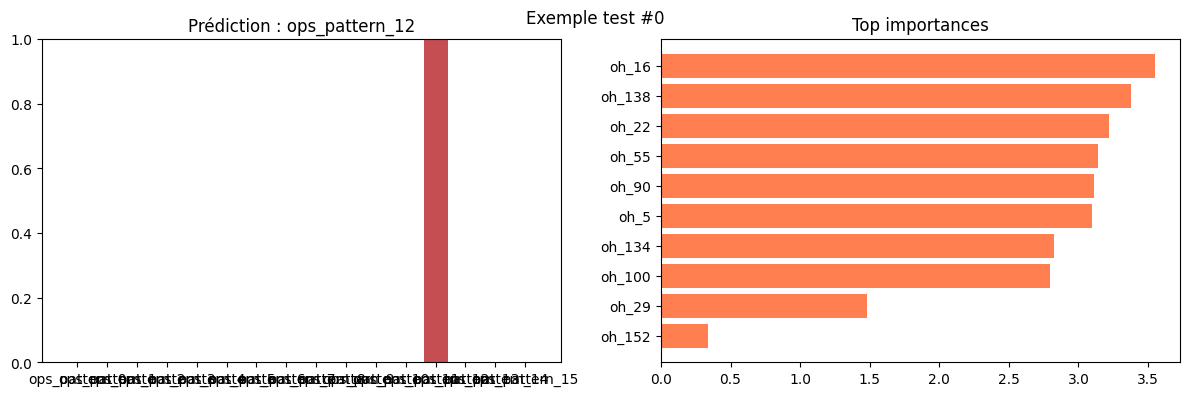

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_1 (idx=1)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 1.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 0.0000
  - ops_pattern_6: 0.0000
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 0.0000
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_130: 3.1582
  - oh_39: 3.0489
  - oh_62: 2.7394
  - oh_95: 1.9029
  - oh_79: 1.7333
  - oh_55: 1.2842
  - oh_151: 0.8260
  - oh_111: 0.7039
  - oh_45: 0.6231
  - oh_140: 0.5252

Règles IF-THEN extraites :
  IF oh_73=+1 AND oh_27=-1 AND oh_6=+1 AND oh_21=+1 THEN ops_pattern_6 (score=0.958)
  IF oh_93=-1 AND oh_12=+1 AND oh_15=+1 AND oh_83=+1 THEN ops_pattern_0 (score=0.919)
  IF oh_18=+1 AND oh_115=+1 AND oh_147=+1 AND oh_37=+1 THEN ops_patter

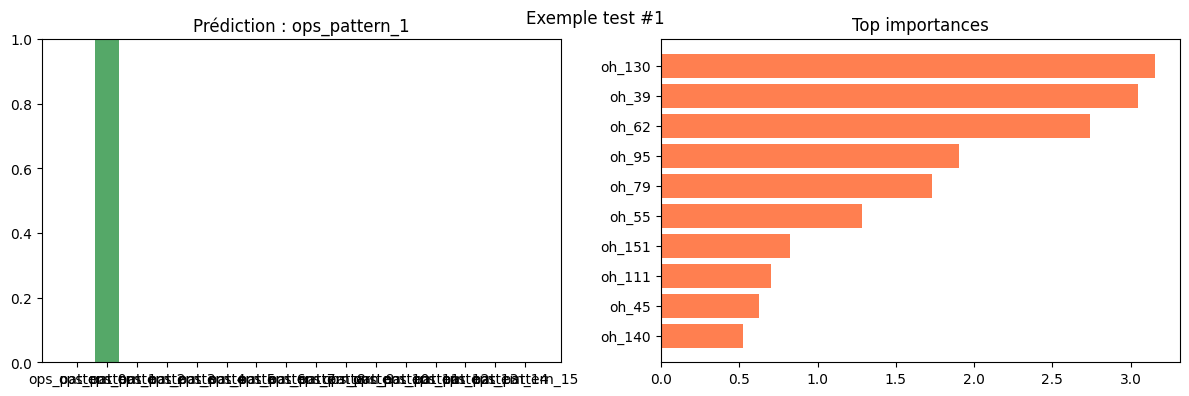

RuleConEx — Rapport d'explication
Prédiction : ops_pattern_5 (idx=5)
Probabilités :
  - ops_pattern_0: 0.0000
  - ops_pattern_1: 0.0000
  - ops_pattern_2: 0.0000
  - ops_pattern_3: 0.0000
  - ops_pattern_4: 0.0000
  - ops_pattern_5: 1.0000
  - ops_pattern_6: 0.0000
  - ops_pattern_7: 0.0000
  - ops_pattern_8: 0.0000
  - ops_pattern_9: 0.0000
  - ops_pattern_10: 0.0000
  - ops_pattern_11: 0.0000
  - ops_pattern_12: 0.0000
  - ops_pattern_13: 0.0000
  - ops_pattern_14: 0.0000
  - ops_pattern_15: 0.0000

Top importances locales (métadonnées) :
  - oh_61: 3.7690
  - oh_16: 3.6148
  - oh_3: 3.5150
  - oh_44: 2.8023
  - oh_23: 2.2586
  - oh_90: 2.1059
  - oh_36: 1.4696
  - oh_104: 1.1104
  - oh_148: 0.7090
  - oh_141: 0.4104

Règles IF-THEN extraites :
  IF oh_55=-1 AND oh_136=+1 AND oh_3=+1 AND oh_87=+1 THEN ops_pattern_5 (score=0.935)
  IF oh_146=-1 AND oh_111=-1 AND oh_105=+1 AND oh_122=+1 THEN ops_pattern_6 (score=0.904)
  IF oh_47=-1 AND oh_129=+1 AND oh_91=-1 AND oh_121=+1 THEN ops_pat

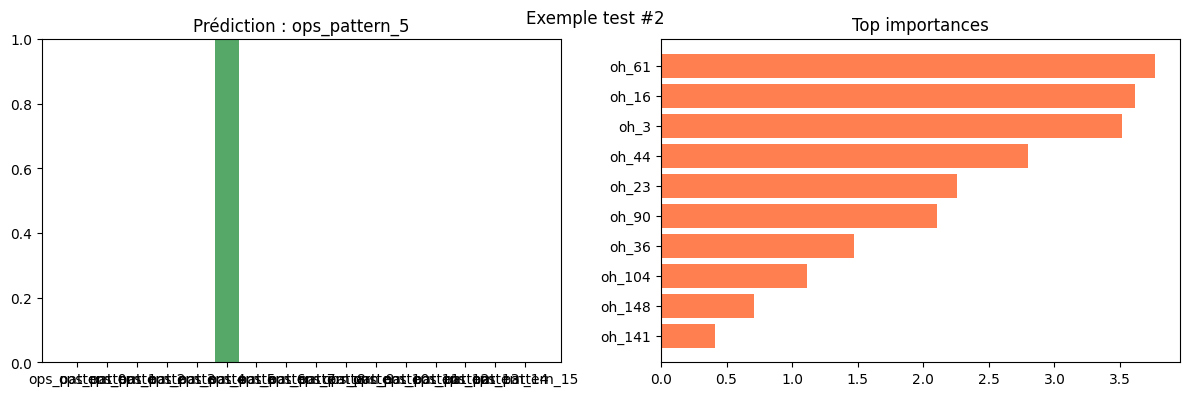

In [12]:
N_EXAMPLES = 3
for i in range(N_EXAMPLES):
    rep = explain_sample(
        model,
        splits.x_test[i],
        None,
        feature_names=splits.feature_names,
        class_names=splits.class_names,
        device=DEVICE,
        top_k=10,
    )
    print(rep.text_report)
    print("\n")
    render_explanation_figure(rep)
    plt.suptitle(f"Exemple test #{i}")
    plt.show()

## 5bis. Contrefactuels — comment lire les métriques ?

**Contexte `u4k-r4k-auth11k`** : 16 classes (`ops_pattern_0` … `ops_pattern_15`), pas binaire grant/deny.

| Métrique | Signification |
|----------|---------------|
| `validity_cf` (96 %) | Sur 100 échantillons × 15 classes alternatives, dans **96 %** des cas le modèle prédit bien la classe cible après modification `x → x'` |
| `n_counterfactuals` (1500) | 100 échantillons × 15 cibles possibles (toutes sauf la vraie classe) |
| `changed_features_mean` | Nombre moyen de colonnes one-hot **activées/désactivées** (vrai flip 0↔1) |
| `proximity_l1_mean` | Distance L1 moyenne `\|x' - x\|` (plus bas = CF plus proche) |
| `flip_success_rate` (100 %) | Chaque échantillon a **au moins un** CF valide vers une autre classe |

**Exemple détaillé** : on part de la **prédiction actuelle** et on montre les **3 meilleures** classes alternatives + métadonnées à changer.

--- Métriques contrefactuelles (test, 100 échantillons) ---
  validity_cf: 0.9600
  changed_features_mean: 10.9033
  proximity_l1_mean: 42.2878
  flip_success_rate: 1.0000
  n_samples_evaluated: 100.0000
  n_counterfactuals: 1500.0000


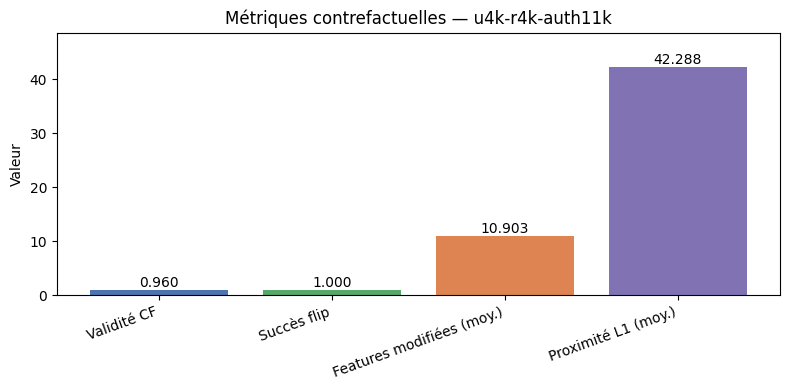


Échantillon test #0 | vraie classe = ops_pattern_12

Prédiction actuelle: ops_pattern_12 → cible: ops_pattern_0
  P(succès)=1.000 | 12 métadonnée(s) modifiée(s)
    oh_5: actif → inactif (1.000 → 0.000)
    oh_16: actif → inactif (1.000 → 0.000)
    oh_22: actif → inactif (1.000 → 0.000)
    oh_29: actif → inactif (1.000 → 0.450)
    oh_40: actif → inactif (1.000 → 0.450)
    oh_49: actif → inactif (1.000 → 0.000)
    oh_75: actif → inactif (1.000 → 0.471)
    oh_100: actif → inactif (1.000 → 0.479)
    oh_115: actif → inactif (1.000 → 0.097)
    oh_125: actif → inactif (1.000 → 0.224)
    oh_138: actif → inactif (1.000 → 0.450)
    oh_152: actif → inactif (1.000 → 0.450)

Prédiction actuelle: ops_pattern_12 → cible: ops_pattern_15
  P(succès)=1.000 | 11 métadonnée(s) modifiée(s)
    oh_5: actif → inactif (1.000 → 0.000)
    oh_16: actif → inactif (1.000 → 0.000)
    oh_22: actif → inactif (1.000 → 0.428)
    oh_40: actif → inactif (1.000 → 0.450)
    oh_49: actif → inactif (1.000 → 0

In [13]:
import importlib
import ruleconex.utils as rc_utils
importlib.reload(rc_utils)
from ruleconex.evaluate import evaluate_counterfactuals

cf_metrics = evaluate_counterfactuals(trainer, splits.x_test, splits.y_test, max_samples=100)
print("--- Métriques contrefactuelles (test, 100 échantillons) ---")
for k, v in cf_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")

plot_counterfactual_metrics(cf_metrics, title=f"Métriques contrefactuelles — {DATASET}")
plt.show()

idx = 0
print(f"\nÉchantillon test #{idx} | vraie classe = {splits.class_names[splits.y_test[idx]]}")
rep_cf = counterfactual_report(
    model,
    splits.x_test[idx],
    int(splits.y_test[idx]),
    splits.feature_names,
    splits.class_names,
    device=DEVICE,
    top_k=3,
)
for cf in rep_cf:
    print(f"\nPrédiction actuelle: {cf['prediction']} → cible: {cf['target_class']}")
    print(f"  P(succès)={cf['cf_success_prob']:.3f} | {cf['n_flips']} métadonnée(s) modifiée(s)")
    if cf["flipped_features"]:
        for flip in cf["flipped_features"]:
            print(f"    {flip['feature']}: {flip['from']} → {flip['to']} ({flip['from_val']:.3f} → {flip['to_val']:.3f})")
    else:
        print("    (aucun flip one-hot net — le CF agit sur des valeurs continues mineures)")

## 6. Monte Carlo à l'inférence (M2 jeux de règles)

À l'entraînement : **M1=3** échantillons MC (diversité KL).
À l'inférence : **M2=5** échantillons, logits moyennés.

In [14]:
x_one = torch.tensor(splits.x_test[:1], dtype=torch.float32, device=DEVICE)
model.eval()
with torch.no_grad():
    pack_m1 = model.forward_pack(x_one, mc_samples=cfg.mc_train_samples)
    pack_m2 = model.forward_pack(x_one, mc_samples=cfg.mc_infer_samples)

print("MC train samples:", len(pack_m1.mc_logits_rules))
print("MC infer samples:", len(pack_m2.mc_logits_rules))
print("Logits M1:", pack_m1.logits_rules.cpu().numpy().round(3))
print("Logits M2 (moyenne):", pack_m2.logits_rules.cpu().numpy().round(3))

MC train samples: 3
MC infer samples: 5
Logits M1: [[-0.453 -3.628 -3.027 -2.059 -6.247 -3.936  1.824 -0.816 -2.949 -3.43
  -0.252 -3.03   9.386 -1.903 -4.157 -4.846]]
Logits M2 (moyenne): [[-0.453 -3.61  -3.034 -2.049 -6.235 -3.932  1.828 -0.815 -2.945 -3.436
  -0.252 -3.039  9.389 -1.918 -4.155 -4.847]]
